# Классификация направления нефтяных «голубых фишек»

Прогноз направления движения цены через `horizon` дней как 3 класса: **0 — падение**, **1 — боковик**, **2 — рост** (граница ±`class_threshold`). Это исследовательский инструмент поддержки решений, не инвестиционная рекомендация.

**Что внутри (с учётом всех прошлых наработок):**
- единый `CONFIG`;
- честная схема **DEV / TEST**: вся настройка и кросс-валидация — на DEV, финальная оценка — **один раз** на отложенном TEST (защита от подгонки под валидацию);
- **walk-forward** кросс-валидация на DEV + **ансамбль по сидам** (усреднение вероятностей) + проверка устойчивости;
- торговые метрики: **precision и edge по сигналам «рост»/«падение»** (точность минус базовая доля класса) — главный продуктовый показатель;
- режим **«осторожности»** через порог уверенности `conf_threshold` (действуем только по уверенным сигналам) и кривая «точность ↔ охват»;
- разбивка по тикерам, матрица ошибок, **permutation importance**;
- защита от утечки: масштабирование только на train, эмбарго в `horizon` дней между блоками.

Запускать на обновлённом `full_df.csv`.

In [ ]:
import os, random, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

def set_seed(s):
    os.environ['PYTHONHASHSEED'] = str(s)
    random.seed(s); np.random.seed(s); tf.random.set_seed(s)

Mounted at /content/drive


In [ ]:
CONFIG = {
    # --- данные ---
    'data_path'      : '/content/drive/MyDrive/full_df_sector.csv',
    'date_start'     : '2015-01-01',
    'date_end'       : '2021-12-31',
    'exclude_tickers': ['SNGS','SNGSP'],
    'drop_columns'   : ['shares_out', 'market_cap', 'Spread_Percent', 'next_div_date'],

    # --- постановка ---
    'horizon'        : 5,      # на сколько дней вперёд смотрим направление
    'window_size'    : 20,
    'class_threshold': 0.013,   # |доходность| < thr -> боковик (класс 1); > thr -> рост (2); < -thr -> падение (0)

    'pct_change_cols': ['imoex', 'rgbi', 'rvi', 'brent', 'usd_rub', 'sp500', 'M2', 'volume', 'value', 'cny_rub'],
    'exclude_features': ['Date', 'target_return', 'close', 'target', 'open', 'high', 'low',
                         'sma_5', 'sma_10', 'sma_20',
                         'rate_is_changed', 'M2', 'm2_is_new', 'fed_rate_proxy',
                         'cny_rub', 'rgbi', 'value', 'brent',
                         'dist_sma_5', 'dist_sma_10',
                         'rate', 'rel_to_imoex', 'rvi',
                         'usd_rub', 'imoex',
                         'volatility_20',
                         'stock_ret_1d', 'sp500', 'oil_in_rub'],

    # --- честная схема оценки ---
    'test_frac'      : 0.2,    # финальная ОТЛОЖЕННАЯ выборка (трогаем один раз в самом конце)
    'n_folds'        : 3,      # walk-forward фолдов внутри DEV (для устойчивости/настройки)
    'val_size'       : 130,    # размер блока валидации на фолд (торговых дней)
    'final_val_size' : 120,    # внутренняя валидация для ранней остановки финальной модели

    # --- ансамбль и модель ---
    'seeds'          : [42, 123, 777, 2024, 7, 8, 9, 10, 11, 12, 13, 14],
    'model'          : {'lstm_units': [32, 16], 'dropout': 0.2, 'dense_units': [16],
                        'lr': 5e-4, 'epochs': 80, 'batch_size': 64, 'patience': 8},

    # --- продукт/интерпретация ---
    'conf_threshold' : 0.40,   # «осторожность»: действуем по сигналу, только если max вероятность >= thr
    'perm_repeats'   : 3,

    'save_dir'       : None,
}

## 1. Загрузка и фильтрация

In [ ]:
df = pd.read_csv(CONFIG['data_path'])
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['Date'].between(CONFIG['date_start'], CONFIG['date_end'])]
df = df[~df['ticker'].isin(CONFIG['exclude_tickers'])]
df = df.drop(columns=[c for c in CONFIG['drop_columns'] if c in df.columns])
print('Период:', df['Date'].min().date(), '—', df['Date'].max().date(),
      '| тикеры:', sorted(df['ticker'].unique()), '| строк:', len(df))

Период: 2015-01-05 — 2021-12-30 | тикеры: ['BANE', 'BANEP', 'GAZP', 'LKOH', 'NVTK', 'ROSN', 'SIBN', 'TATN', 'TATNP'] | строк: 15885


## 2. Признаки и таргет (тот же пайплайн, что в регрессии)

In [ ]:
def prepare_data(df, cfg):
    data = df.copy().sort_values(['ticker', 'Date'])
    h = cfg['horizon']
    data['target_return'] = data.groupby('ticker')['close'].shift(-h) / data['close'] - 1
    data['oil_in_rub'] = data['brent'] * data['usd_rub']
    data['oil_in_rub'] = data.groupby('ticker')['oil_in_rub'].pct_change()
    for col in cfg['pct_change_cols']:
        if col in data.columns:
            data[col] = data.groupby('ticker')[col].pct_change()
    data['stock_ret_1d'] = data.groupby('ticker')['close'].pct_change()

    data['rel_to_imoex'] = data['stock_ret_1d'] - data['imoex']
    data['stock_ret_5d'] = data.groupby('ticker')['stock_ret_1d'].transform(lambda x: x.rolling(5).mean())
    data['mkt_vol_20']   = data.groupby('ticker')['imoex'].transform(lambda x: x.rolling(20).std())  # волатильность рынка

    # реализованная волатильность за 20 дней
    data['volatility_20'] = data.groupby('ticker')['stock_ret_1d'].transform(lambda x: x.rolling(20).std())
    # относительный объём (объём / своя 20-дневная средняя)
    data['rel_volume'] = data.groupby('ticker')['volume'].transform(lambda x: x / x.rolling(20).mean())
    if {'high', 'low'}.issubset(data.columns):
        data['range_pct'] = (data['high'] - data['low']) / data['close']
    data = pd.get_dummies(data, columns=['ticker'], prefix='ticker', dtype=float)
    feature_cols = [c for c in data.columns if c not in cfg['exclude_features']]
    data = data.replace([np.inf, -np.inf], np.nan).dropna(subset=feature_cols + ['target_return'])
    return data, feature_cols


def make_3_classes(y, thr):
    # 0 = падение, 1 = боковик, 2 = рост
    return np.select([y < -thr, y > thr], [0, 2], default=1).astype('int64')

df_clean, FEATURES = prepare_data(df, CONFIG)
W = CONFIG['window_size']
_lbl = make_3_classes(df_clean['target_return'].values, CONFIG['class_threshold'])
print(f'Признаков: {len(FEATURES)} | строк: {len(df_clean)}')
print('Баланс классов (0 падение / 1 боковик / 2 рост):', np.bincount(_lbl) / len(_lbl))

Признаков: 18 | строк: 15244
Баланс классов (0 падение / 1 боковик / 2 рост): [0.30516925 0.34689058 0.34794017]


## 3. Вспомогательные функции

In [ ]:
def create_sequences(frame, feature_cols, window_size, target_col='target_return'):
    Xs, ys, ds, ts = [], [], [], []
    for tcol in [c for c in frame.columns if c.startswith('ticker_')]:
        sub = frame[frame[tcol] == 1.0].sort_values('Date')
        if len(sub) <= window_size:
            continue
        feats = sub[feature_cols].values.astype('float32')
        tgt = sub[target_col].values.astype('float32')
        dates = sub['Date'].values
        name = tcol.replace('ticker_', '')
        for i in range(window_size, len(sub)):
            Xs.append(feats[i - window_size:i]); ys.append(tgt[i])
            ds.append(dates[i]); ts.append(name)
    return np.array(Xs), np.array(ys), np.array(ds), np.array(ts)


def scale_fit_transform(train_df, others, feature_cols):
    """Scaler учится на train_df; применяется к train_df и каждому df из others."""
    binary = [c for c in feature_cols if c.startswith('ticker_')
              or c.endswith('is_changed') or c.endswith('is_new')]
    scale_cols = [c for c in feature_cols if c not in binary]
    sc = RobustScaler()
    tr = train_df.copy(); tr[scale_cols] = sc.fit_transform(tr[scale_cols])
    tr[feature_cols] = tr[feature_cols].astype('float32')
    out = []
    for o in others:
        oo = o.copy(); oo[scale_cols] = sc.transform(oo[scale_cols])
        oo[feature_cols] = oo[feature_cols].astype('float32'); out.append(oo)
    return tr, out, sc


def build_model(input_shape, m):
    layers = [Input(shape=input_shape)]
    units = m['lstm_units']
    for j, u in enumerate(units):
        layers.append(LSTM(u, return_sequences=(j < len(units) - 1)))
        layers.append(Dropout(m['dropout']))
        if j == 0:
            layers.append(BatchNormalization())
    for du in m['dense_units']:
        layers.append(Dense(du, activation='relu'))
    layers.append(Dense(3, activation='softmax'))
    model = Sequential(layers)
    model.compile(optimizer=Adam(m['lr']), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def class_weights(y):
    cl = np.unique(y)
    w = compute_class_weight('balanced', classes=cl, y=y)
    return {int(c): float(wi) for c, wi in zip(cl, w)}


def train_ensemble(Xtr, ytr, Xval, yval, n_feat, mcfg, seeds):
    cw = class_weights(ytr); models, hist0 = [], None
    for s in seeds:
        set_seed(s)
        model = build_model((W, n_feat), mcfg)
        h = model.fit(Xtr, ytr, validation_data=(Xval, yval), epochs=mcfg['epochs'],
                      batch_size=mcfg['batch_size'], class_weight=cw, verbose=0,
                      callbacks=[EarlyStopping(patience=mcfg['patience'], restore_best_weights=True),
                                 ReduceLROnPlateau(factor=0.5, patience=max(3, mcfg['patience'] // 2))])
        models.append(model)
        if hist0 is None: hist0 = h
    return models, hist0


def ensemble_proba(models, X):
    return np.mean([m.predict(X, verbose=0) for m in models], axis=0)


def trading_metrics(y_true, probs, conf=0.0):
    """Главные продуктовые метрики: precision и edge по сигналам рост/падение.
    conf>0 включает «осторожность»: учитываем сигнал, только если max вероятность >= conf."""
    pred = np.argmax(probs, axis=1); confident = probs.max(axis=1) >= conf
    res = {'accuracy': float(np.mean(pred == y_true)),
           'majority': float(np.bincount(y_true, minlength=3).max() / len(y_true))}
    for cls, name in [(2, 'up'), (0, 'down')]:
        sig = (pred == cls) & confident
        base = float(np.mean(y_true == cls))
        if sig.sum() > 0:
            prec = float(np.mean(y_true[sig] == cls)); cov = float(np.mean(sig))
            res[f'{name}_precision'] = prec; res[f'{name}_coverage'] = cov
            res[f'{name}_edge'] = prec - base
        else:
            res[f'{name}_precision'] = np.nan; res[f'{name}_coverage'] = 0.0; res[f'{name}_edge'] = np.nan
        res[f'{name}_base'] = base
    res['n'] = int(len(y_true))
    return res

## 4. Схема оценки: DEV / TEST + walk-forward на DEV

TEST — последний `test_frac` периода — откладывается и используется один раз в самом конце. Всё остальное (DEV) идёт на кросс-валидацию и настройку. Между всеми блоками — эмбарго в `horizon` дней.

In [ ]:
def split_dev_test(dates, test_frac, embargo):
    dates = sorted(pd.unique(dates))
    cut = int(len(dates) * (1 - test_frac))
    return dates[:cut - embargo], dates[cut:]

def walk_forward(dev_dates, n_folds, val_size, embargo):
    dev = sorted(pd.unique(dev_dates)); first = len(dev) - n_folds * val_size
    if first < val_size:
        raise ValueError('Мало дат для n_folds/val_size — уменьшите их в CONFIG.')
    out = []
    for k in range(n_folds):
        vs = first + k * val_size
        out.append((dev[:vs - embargo], dev[vs:vs + val_size]))
    return out

EMB = CONFIG['horizon']
DEV, TEST = split_dev_test(df_clean['Date'], CONFIG['test_frac'], EMB)
FOLDS = walk_forward(DEV, CONFIG['n_folds'], CONFIG['val_size'], EMB)
print('DEV :', pd.Timestamp(DEV[0]).date(), '..', pd.Timestamp(DEV[-1]).date(), f'({len(DEV)} дней)')
print('TEST:', pd.Timestamp(TEST[0]).date(), '..', pd.Timestamp(TEST[-1]).date(), f'({len(TEST)} дней) — трогаем один раз')
for k, (tr, va) in enumerate(FOLDS):
    print(f'  fold {k}: train {len(tr)} | val {len(va)} дней')

DEV : 2015-02-03 .. 2020-08-06 (1387 дней)
TEST: 2020-08-14 .. 2021-12-23 (348 дней) — трогаем один раз
  fold 0: train 992 | val 130 дней
  fold 1: train 1122 | val 130 дней
  fold 2: train 1252 | val 130 дней


## 5. Walk-forward кросс-валидация на DEV (устойчивость)

Здесь оцениваем устойчивость и здесь же можно подбирать решения. TEST не трогаем.

In [ ]:
THR = CONFIG['class_threshold']
mcfg = CONFIG['model']
seeds = CONFIG['seeds']

cv_rows, cv_seed_rows = [], []
cv_folds_artifacts = []

for k, (tr_dates, va_dates) in enumerate(FOLDS):
    tr_df = df_clean[df_clean['Date'].isin(tr_dates)]
    va_df = df_clean[df_clean['Date'].isin(va_dates)]
    tr_s, (va_s,), _ = scale_fit_transform(tr_df, [va_df], FEATURES)
    Xtr, ytr_r, _, _ = create_sequences(tr_s, FEATURES, W)
    Xva, yva_r, _, _ = create_sequences(va_s, FEATURES, W)
    if len(Xtr) == 0 or len(Xva) == 0:
        print(f'fold {k}: мало данных'); continue
    ytr, yva = make_3_classes(ytr_r, THR), make_3_classes(yva_r, THR)

    models, _ = train_ensemble(Xtr, ytr, Xva, yva, len(FEATURES), mcfg, seeds)
    cv_folds_artifacts.append({'models': models, 'Xva': Xva, 'yva': yva})
    # устойчивость по сидам
    for s, m in zip(seeds, models):
        sm = trading_metrics(yva, m.predict(Xva, verbose=0)); sm.update({'fold': k, 'seed': s}); cv_seed_rows.append(sm)
    fm = trading_metrics(yva, ensemble_proba(models, Xva)); fm['fold'] = k; cv_rows.append(fm)
    print(f"fold {k}: acc={fm['accuracy']:.3f} (majority {fm['majority']:.3f}) | "
          f"UP precision={fm['up_precision']:.3f} (base {fm['up_base']:.3f}, edge {fm['up_edge']:+.3f}, "
          f"coverage {fm['up_coverage']:.3f})")

cv = pd.DataFrame(cv_rows); cv_seeds = pd.DataFrame(cv_seed_rows)

fold 0: acc=0.369 (majority 0.405) | UP precision=0.351 (base 0.338, edge +0.013, coverage 0.593)
fold 1: acc=0.425 (majority 0.445) | UP precision=0.366 (base 0.322, edge +0.044, coverage 0.339)
fold 2: acc=0.443 (majority 0.406) | UP precision=0.494 (base 0.406, edge +0.088, coverage 0.551)


=== Walk-forward CV (ансамбль): среднее +- разброс по фолдам ===
                  mean     std
accuracy        0.4125  0.0390
majority        0.4189  0.0230
up_precision    0.4035  0.0784
up_base         0.3556  0.0445
up_edge         0.0480  0.0377
up_coverage     0.4943  0.1358
down_precision  0.3034  0.0576
down_edge       0.0354  0.0689

=== Устойчивость UP-edge по сидам внутри фолдов ===
        mean     std     min     max
fold                                
0    -0.0037  0.0221 -0.0471  0.0376
1     0.0450  0.0327  0.0091  0.1143
2     0.0850  0.0145  0.0671  0.1081


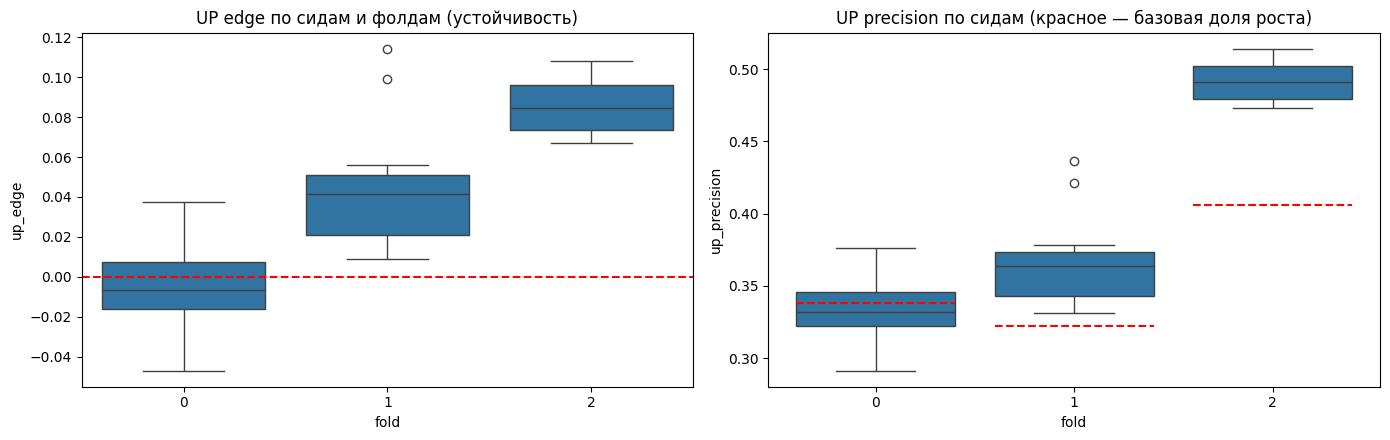

In [ ]:
cols = ['accuracy', 'majority', 'up_precision', 'up_base', 'up_edge', 'up_coverage', 'down_precision', 'down_edge']
print('=== Walk-forward CV (ансамбль): среднее +- разброс по фолдам ===')
print(cv[cols].agg(['mean', 'std']).T.round(4).to_string())
print('\n=== Устойчивость UP-edge по сидам внутри фолдов ===')
print(cv_seeds.groupby('fold')['up_edge'].agg(['mean', 'std', 'min', 'max']).round(4).to_string())

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=cv_seeds, x='fold', y='up_edge', ax=ax[0]); ax[0].axhline(0, ls='--', c='red')
ax[0].set_title('UP edge по сидам и фолдам (устойчивость)')
sns.boxplot(data=cv_seeds, x='fold', y='up_precision', ax=ax[1])
for k in cv['fold']:
    ax[1].hlines(cv.loc[cv.fold == k, 'up_base'].values[0], k - 0.4, k + 0.4, color='red', ls='--')
ax[1].set_title('UP precision по сидам (красное — базовая доля роста)')
plt.tight_layout(); plt.show()

               fold0   fold1   fold2    mean     std
feature                                             
mkt_vol_20   -0.0131  0.0010  0.0798  0.0226  0.0501
ticker_ROSN   0.0064  0.0199 -0.0020  0.0081  0.0110
ticker_LKOH   0.0017  0.0088  0.0077  0.0061  0.0038
ticker_GAZP   0.0084  0.0027  0.0057  0.0056  0.0029
volume        0.0185 -0.0030 -0.0010  0.0048  0.0119
ticker_NVTK   0.0010  0.0054 -0.0007  0.0019  0.0031
ticker_TATNP  0.0027  0.0040 -0.0020  0.0016  0.0032
ticker_BANE   0.0051 -0.0071  0.0054  0.0011  0.0071
ROE          -0.0051  0.0094 -0.0017  0.0009  0.0076
ticker_TATN   0.0034  0.0013 -0.0030  0.0006  0.0033
range_pct     0.0088 -0.0007 -0.0071  0.0003  0.0080
days_to_div   0.0044  0.0051 -0.0108 -0.0004  0.0089
ticker_SIBN   0.0088 -0.0071 -0.0077 -0.0020  0.0093
rel_volume   -0.0013 -0.0037 -0.0020 -0.0024  0.0012
dist_sma_20  -0.0003 -0.0094 -0.0010 -0.0036  0.0051
dividend_val -0.0034 -0.0061 -0.0013 -0.0036  0.0024
ticker_BANEP -0.0064  0.0000 -0.0064 -0.0043  

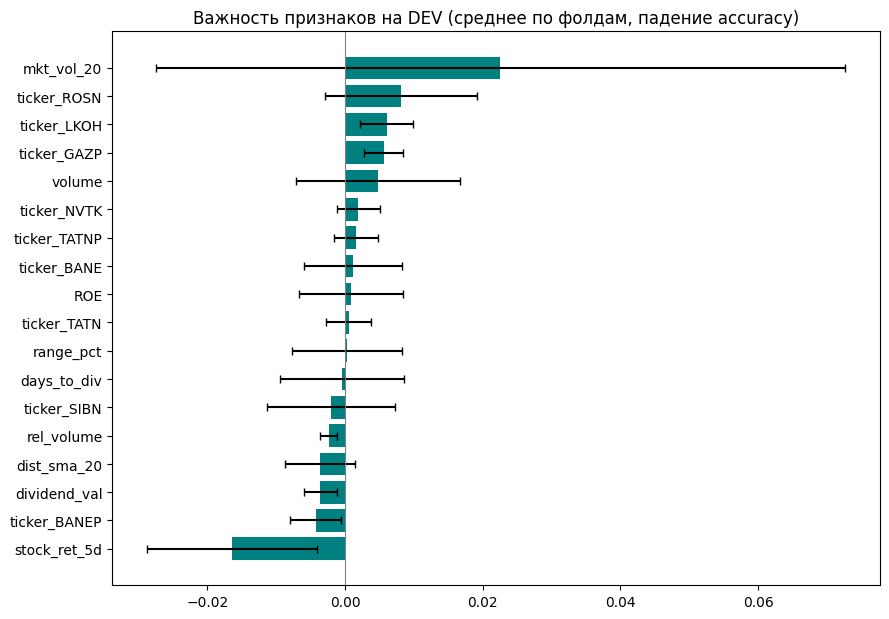

In [ ]:
# === Важность признаков на DEV (по валидационным блокам фолдов) ===
# Считаем permutation importance на валидации каждого фолда и усредняем по фолдам.
# Это часть DEV, не TEST — на эти числа можно опираться при отборе признаков.
def permutation_importance(models, X, y, feature_cols, n_repeats=3):
    base_acc = np.mean(np.argmax(ensemble_proba(models, X), axis=1) == y)
    rows = []
    for fi, fname in enumerate(feature_cols):
        drops = []
        for _ in range(n_repeats):
            Xp = X.copy()
            Xp[:, :, fi] = Xp[np.random.permutation(Xp.shape[0]), :, fi]
            acc = np.mean(np.argmax(ensemble_proba(models, Xp), axis=1) == y)
            drops.append(base_acc - acc)
        rows.append({'feature': fname, 'imp': np.mean(drops)})
    return pd.DataFrame(rows).set_index('feature')['imp']

imp_per_fold = []
for k, art in enumerate(cv_folds_artifacts):
    imp_per_fold.append(permutation_importance(art['models'], art['Xva'], art['yva'],
                                                FEATURES, CONFIG['perm_repeats']))
imp_dev = pd.concat(imp_per_fold, axis=1)
imp_dev.columns = [f'fold{k}' for k in range(len(imp_per_fold))]
imp_dev['mean'] = imp_dev.mean(axis=1)
imp_dev['std'] = imp_dev[[f'fold{k}' for k in range(len(imp_per_fold))]].std(axis=1)
imp_dev = imp_dev.sort_values('mean', ascending=False)
print(imp_dev.round(4).to_string())

top = imp_dev.head(20)[::-1]
plt.figure(figsize=(9, max(4, 0.35 * len(top))))
plt.barh(top.index, top['mean'], xerr=top['std'], capsize=3, color='teal')
plt.axvline(0, c='gray', lw=0.8)
plt.title('Важность признаков на DEV (среднее по фолдам, падение accuracy)')
plt.tight_layout(); plt.show()

Средняя базовая доля роста по фолдам: 0.356
 conf  up_precision  up_coverage  up_edge  folds_with_signals
 0.35         0.409        0.438    0.053                   3
 0.36         0.408        0.371    0.052                   3
 0.37         0.409        0.288    0.053                   3
 0.38         0.401        0.234    0.046                   3
 0.39         0.417        0.205    0.062                   3
 0.40         0.485        0.271    0.120                   2
 0.41         0.564        0.238    0.200                   2
 0.42         0.558        0.218    0.194                   2
 0.43         0.566        0.204    0.202                   2
 0.44         0.567        0.192    0.203                   2
 0.45         0.585        0.178    0.221                   2
 0.46         0.585        0.162    0.221                   2
 0.47         0.589        0.125    0.225                   2
 0.48         0.597        0.078    0.233                   2
 0.49         0.615       

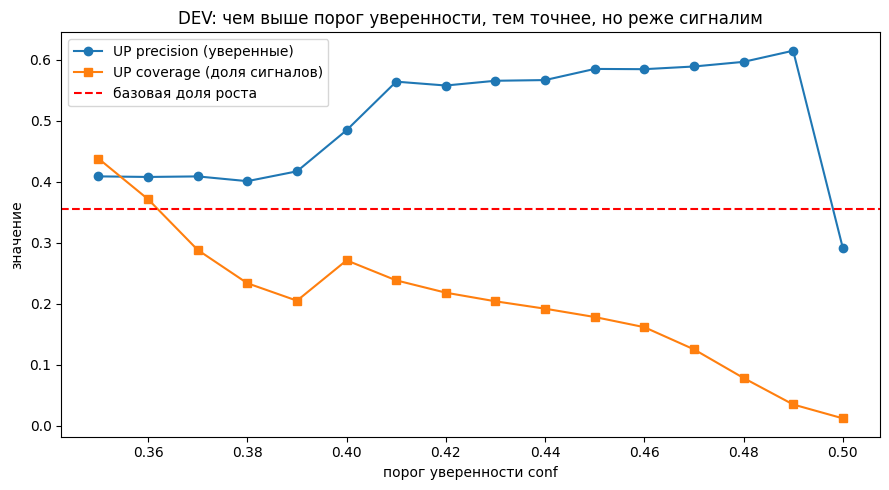

In [ ]:
# === Кривая «уверенность → точность/охват» на DEV (по валидации фолдов) ===
# Проверяем: если действовать только по уверенным сигналам "рост", растёт ли precision над базой?
# Всё считается на валидации фолдов (DEV), не на TEST.
confs = np.round(np.arange(0.35, 0.50, 0.01), 2)

rows = []
for c in confs:
    precs, covs, edges = [], [], []
    for art in cv_folds_artifacts:
        probs = ensemble_proba(art['models'], art['Xva'])
        y = art['yva']
        pred = np.argmax(probs, axis=1)
        confident = probs.max(axis=1) >= c
        sig = (pred == 2) & confident          # уверенные сигналы "рост"
        #sig = probs[:, 2] >= c
        base = np.mean(y == 2)                  # базовая доля роста в этом фолде
        if sig.sum() > 0:
            precs.append(np.mean(y[sig] == 2))
            covs.append(np.mean(sig))
            edges.append(np.mean(y[sig] == 2) - base)
    # усредняем по фолдам (где сигналы вообще были)
    rows.append({'conf': c,
                 'up_precision': np.mean(precs) if precs else np.nan,
                 'up_coverage':  np.mean(covs)  if covs  else 0.0,
                 'up_edge':      np.mean(edges) if edges else np.nan,
                 'folds_with_signals': len(precs)})

sweep_dev = pd.DataFrame(rows)
base_up = np.mean([np.mean(art['yva'] == 2) for art in cv_folds_artifacts])

print(f'Средняя базовая доля роста по фолдам: {base_up:.3f}')
print(sweep_dev.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sweep_dev['conf'], sweep_dev['up_precision'], 'o-', label='UP precision (уверенные)')
ax.plot(sweep_dev['conf'], sweep_dev['up_coverage'], 's-', label='UP coverage (доля сигналов)')
ax.axhline(base_up, ls='--', c='red', label='базовая доля роста')
ax.set_xlabel('порог уверенности conf'); ax.set_ylabel('значение')
ax.set_title('DEV: чем выше порог уверенности, тем точнее, но реже сигналим')
ax.legend(); plt.tight_layout(); plt.show()

## 6. Финальная оценка на отложенном TEST (один раз)

Финальный ансамбль учится на DEV (ранняя остановка — на внутренней валидации в конце DEV) и оценивается на TEST, который мы до сих пор не трогали.

In [ ]:
dev_df = df_clean[df_clean['Date'].isin(DEV)]
test_df = df_clean[df_clean['Date'].isin(TEST)]

# масштабирование: учимся на DEV, применяем к TEST (TEST остаётся невиданным для обучения)
dev_s, (test_s,), final_scaler = scale_fit_transform(dev_df, [test_df], FEATURES)

# внутри DEV выделяем хвост для ранней остановки
dev_dates_sorted = sorted(pd.unique(DEV))
fv = CONFIG['final_val_size']
tr_final_dates = dev_dates_sorted[:-(fv + EMB)]
val_final_dates = dev_dates_sorted[-fv:]
trf = dev_s[dev_s['Date'].isin(tr_final_dates)]
vlf = dev_s[dev_s['Date'].isin(val_final_dates)]

Xtrf, ytrf_r, _, _ = create_sequences(trf, FEATURES, W)
Xvlf, yvlf_r, _, _ = create_sequences(vlf, FEATURES, W)
Xte, yte_r, dte, tte = create_sequences(test_s, FEATURES, W)
ytrf, yvlf, yte = make_3_classes(ytrf_r, THR), make_3_classes(yvlf_r, THR), make_3_classes(yte_r, THR)

final_models, final_hist = train_ensemble(Xtrf, ytrf, Xvlf, yvlf, len(FEATURES), mcfg, seeds)
probs_te = ensemble_proba(final_models, Xte)

base = trading_metrics(yte, probs_te, conf=0.0)
cautious = trading_metrics(yte, probs_te, conf=CONFIG['conf_threshold'])
print('=== TEST (все сигналы) ===')
for kk in ['accuracy', 'majority', 'up_precision', 'up_base', 'up_edge', 'up_coverage', 'down_precision', 'down_edge', 'n']:
    print(f'  {kk:14s}: {base[kk]:.3f}' if isinstance(base[kk], float) else f'  {kk:14s}: {base[kk]}')
print(f"\n=== TEST (осторожно, conf>={CONFIG['conf_threshold']}) ===")
for kk in ['up_precision', 'up_coverage', 'up_edge', 'down_precision', 'down_coverage']:
    print(f'  {kk:14s}: {cautious[kk]:.3f}')

=== TEST (все сигналы) ===
  accuracy      : 0.356
  majority      : 0.339
  up_precision  : 0.359
  up_base       : 0.339
  up_edge       : 0.020
  up_coverage   : 0.351
  down_precision: 0.332
  down_edge     : -0.004
  n             : 2952

=== TEST (осторожно, conf>=0.4) ===
  up_precision  : 0.345
  up_coverage   : 0.232
  up_edge       : 0.006
  down_precision: 0.339
  down_coverage : 0.256


## 7. Кривая «точность ↔ охват» по порогу уверенности (режим осторожности)

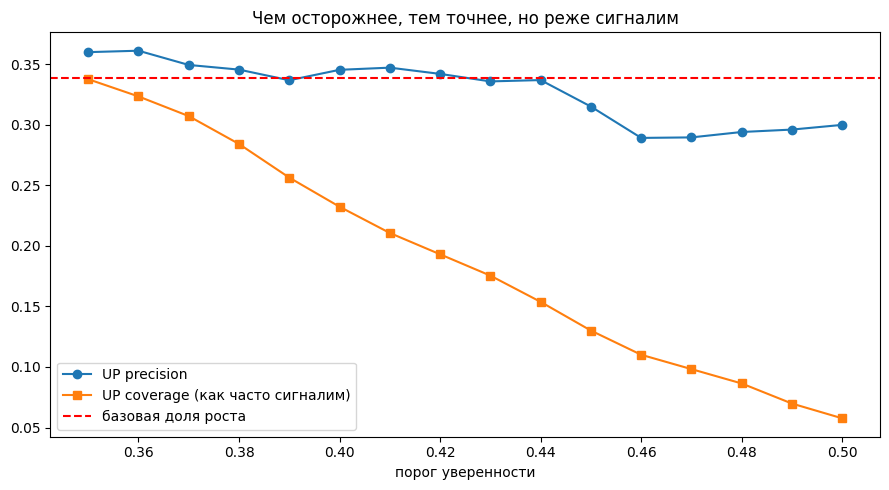

 conf  up_precision  up_coverage  up_edge
 0.35         0.360        0.338    0.021
 0.36         0.361        0.324    0.022
 0.37         0.350        0.307    0.010
 0.38         0.346        0.284    0.007
 0.39         0.337        0.256   -0.002
 0.40         0.345        0.232    0.006
 0.41         0.347        0.211    0.008
 0.42         0.342        0.193    0.003
 0.43         0.336        0.175   -0.003
 0.44         0.337        0.154   -0.002
 0.45         0.315        0.130   -0.024
 0.46         0.289        0.110   -0.050
 0.47         0.290        0.098   -0.049
 0.48         0.294        0.086   -0.045
 0.49         0.296        0.070   -0.043
 0.50         0.300        0.058   -0.039


In [ ]:
confs = np.round(np.arange(0.35, 0.50, 0.01), 2)
rows = [dict(conf=c, **{k: trading_metrics(yte, probs_te, c)[k] for k in
            ['up_precision', 'up_coverage', 'up_edge']}) for c in confs]
sweep = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sweep['conf'], sweep['up_precision'], 'o-', label='UP precision')
ax.plot(sweep['conf'], sweep['up_coverage'], 's-', label='UP coverage (как часто сигналим)')
ax.axhline(base['up_base'], ls='--', c='red', label='базовая доля роста')
ax.set_xlabel('порог уверенности'); ax.set_title('Чем осторожнее, тем точнее, но реже сигналим')
ax.legend(); plt.tight_layout(); plt.show()
print(sweep.round(3).to_string(index=False))

## 8. Разбивка по тикерам и матрица ошибок (TEST)

Ticker  Accuracy  UP_precision  UP_base  UP_coverage   N
  ROSN     0.372         0.453    0.421        0.195 328
  NVTK     0.405         0.404    0.360        0.573 328
  LKOH     0.363         0.400    0.366        0.442 328
  GAZP     0.308         0.393    0.454        0.085 328
  SIBN     0.302         0.378    0.415        0.250 328
 TATNP     0.329         0.336    0.317        0.845 328
  TATN     0.335         0.321    0.311        0.588 328
 BANEP     0.369         0.256    0.213        0.131 328
  BANE     0.418         0.067    0.195        0.046 328


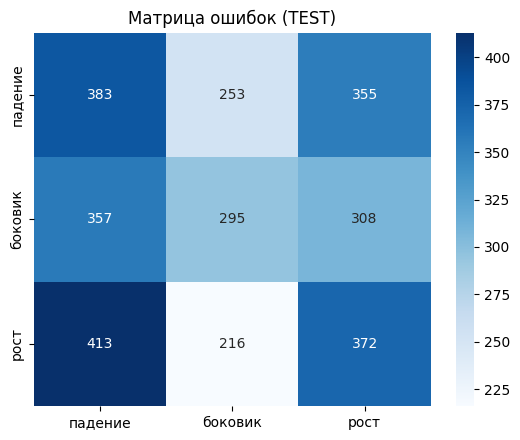

In [ ]:
pred_te = np.argmax(probs_te, axis=1)
rows = []
for name in np.unique(tte):
    m = tte == name; yt = yte[m]; pr = pred_te[m]
    up = pr == 2
    rows.append({'Ticker': name, 'Accuracy': np.mean(pr == yt),
                 'UP_precision': (np.mean(yt[up] == 2) if up.sum() else np.nan),
                 'UP_base': np.mean(yt == 2),
                 'UP_coverage': np.mean(up), 'N': int(m.sum())})
print(pd.DataFrame(rows).sort_values('UP_precision', ascending=False)
      .to_string(index=False, float_format=lambda x: f'{x:.3f}'))

cm = pd.crosstab(pd.Series(yte, name='Факт'), pd.Series(pred_te, name='Прогноз'))
cm = cm.reindex(index=[0, 1, 2], columns=[0, 1, 2], fill_value=0)
cm.index = ['падение', 'боковик', 'рост']; cm.columns = ['падение', 'боковик', 'рост']
plt.figure(figsize=(5.5, 4.5)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок (TEST)'); plt.tight_layout(); plt.show()

## 9. Важность признаков (permutation importance, TEST)

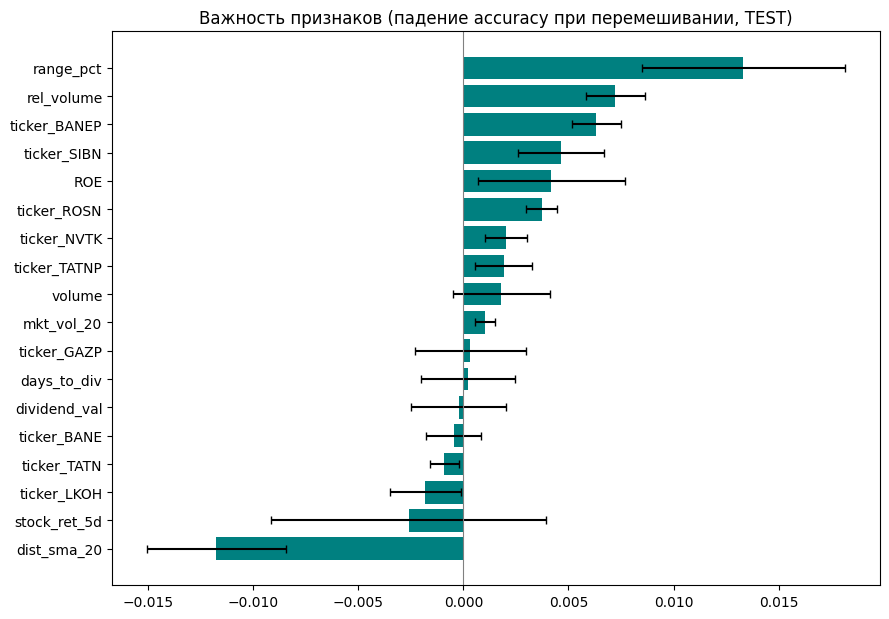

     feature  imp_mean  imp_std
   range_pct    0.0133   0.0048
  rel_volume    0.0072   0.0014
ticker_BANEP    0.0063   0.0012
 ticker_SIBN    0.0046   0.0020
         ROE    0.0042   0.0035
 ticker_ROSN    0.0037   0.0007
 ticker_NVTK    0.0020   0.0010
ticker_TATNP    0.0019   0.0014
      volume    0.0018   0.0023
  mkt_vol_20    0.0010   0.0005
 ticker_GAZP    0.0003   0.0026
 days_to_div    0.0002   0.0022
dividend_val   -0.0002   0.0023
 ticker_BANE   -0.0005   0.0013
 ticker_TATN   -0.0009   0.0007
 ticker_LKOH   -0.0018   0.0017
stock_ret_5d   -0.0026   0.0065
 dist_sma_20   -0.0117   0.0033


In [ ]:
def permutation_importance(models, X, y, feature_cols, n_repeats=3):
    base_acc = np.mean(np.argmax(ensemble_proba(models, X), axis=1) == y)
    rows = []
    for fi, fname in enumerate(feature_cols):
        drops = []
        for _ in range(n_repeats):
            Xp = X.copy(); Xp[:, :, fi] = Xp[np.random.permutation(Xp.shape[0]), :, fi]
            acc = np.mean(np.argmax(ensemble_proba(models, Xp), axis=1) == y)
            drops.append(base_acc - acc)
        rows.append({'feature': fname, 'imp_mean': np.mean(drops), 'imp_std': np.std(drops)})
    return pd.DataFrame(rows).sort_values('imp_mean', ascending=False)

imp = permutation_importance(final_models, Xte, yte, FEATURES, CONFIG['perm_repeats'])
top = imp.head(20)[::-1]
plt.figure(figsize=(9, max(4, 0.35 * len(top))))
plt.barh(top['feature'], top['imp_mean'], xerr=top['imp_std'], capsize=3, color='teal')
plt.axvline(0, c='gray', lw=0.8); plt.title('Важность признаков (падение accuracy при перемешивании, TEST)')
plt.tight_layout(); plt.show()
print(imp.round(4).to_string(index=False))

## 11. Доработка: адаптированные метрики (bias / WAPE) и SHAP-диагностика

In [ ]:
def calibration_bias_wape(y_true, probs, class_names=('падение', 'боковик', 'рост')):
    """Адаптация WAPE/bias для классификации: bias — систематическое
    смещение доли предсказаний класса относительно факта; wape — линейная
    (не квадратичная) мера ошибки калибровки вероятностей по классу."""
    onehot = np.eye(probs.shape[1])[y_true]
    rows = []
    for c, name in enumerate(class_names):
        true_rate = onehot[:, c].mean()
        pred_rate = probs[:, c].mean()
        bias = pred_rate - true_rate                      # + = модель переоценивает класс, - = недооценивает
        wape = np.abs(onehot[:, c] - probs[:, c]).sum() / max(onehot[:, c].sum(), 1)
        rows.append({'class': name, 'true_rate': true_rate,
                      'pred_rate': pred_rate, 'bias': bias, 'wape': wape})
    return pd.DataFrame(rows)

metrics_bw = calibration_bias_wape(yte, probs_te)
print('=== Bias / WAPE по классам (TEST) ===')
print(metrics_bw.round(4).to_string(index=False))

=== Bias / WAPE по классам (TEST) ===
  class  true_rate  pred_rate    bias   wape
падение     0.3357     0.3330 -0.0027 1.3296
боковик     0.3252     0.3268  0.0016 1.3259
   рост     0.3391     0.3402  0.0011 1.3200


In [ ]:
rows = []
for k, art in enumerate(cv_folds_artifacts):
    p = ensemble_proba(art['models'], art['Xva'])
    t = calibration_bias_wape(art['yva'], p)
    t['fold'] = k
    rows.append(t)
metrics_bw_folds = pd.concat(rows, ignore_index=True)
print(metrics_bw_folds.round(4).to_string(index=False))

  class  true_rate  pred_rate    bias   wape  fold
падение     0.2566     0.3112  0.0546 1.5919     0
боковик     0.4051     0.3410 -0.0641 1.1578     0
   рост     0.3384     0.3479  0.0095 1.3308     0
падение     0.2323     0.2758  0.0435 1.5787     1
боковик     0.4455     0.3836 -0.0619 1.0715     1
   рост     0.3222     0.3406  0.0184 1.3561     1
падение     0.3152     0.3206  0.0054 1.3564     2
боковик     0.2788     0.2996  0.0208 1.4178     2
   рост     0.4061     0.3799 -0.0262 1.1229     2


In [ ]:
!pip install -q shap
import shap

<class 'numpy.ndarray'>
(300, 20, 18, 3)
     feature  mean_abs_shap
  rel_volume       0.004059
stock_ret_5d       0.003973
   range_pct       0.002995
         ROE       0.002527
 days_to_div       0.001997
      volume       0.001833
  mkt_vol_20       0.001820
ticker_TATNP       0.001443
 dist_sma_20       0.001429
 ticker_SIBN       0.000831
 ticker_TATN       0.000790
 ticker_NVTK       0.000688
 ticker_ROSN       0.000639
 ticker_BANE       0.000606
 ticker_LKOH       0.000553


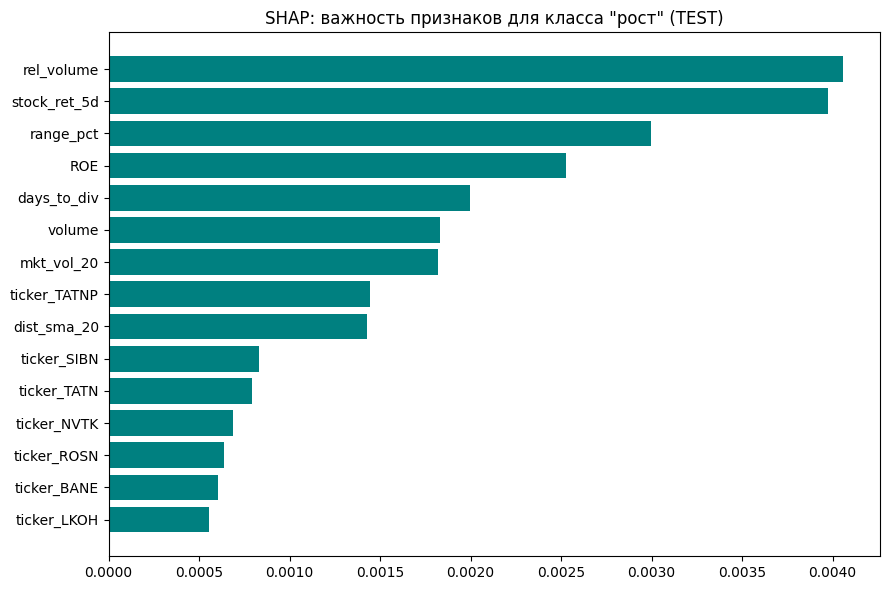

In [ ]:
rng = np.random.default_rng(42)

bg_idx = rng.choice(len(Xtrf), size=100, replace=False)
background = Xtrf[bg_idx]

n_explain = 300
ex_idx = rng.choice(len(Xte), size=min(n_explain, len(Xte)), replace=False)
X_explain = Xte[ex_idx]

explainer = shap.GradientExplainer(final_models[0], background)
shap_values = explainer.shap_values(X_explain)


print(type(shap_values))
if isinstance(shap_values, list):
    print([x.shape for x in shap_values])
else:
    print(np.asarray(shap_values).shape)

# агрегируем: |SHAP| усредняем по временным шагам окна -> вклад признака целиком
# def aggregate_shap(shap_values, class_idx, feature_names):
#     sv = shap_values[class_idx]                  # (n, window, n_feat)
#     imp = np.abs(sv).mean(axis=(0, 1))            # среднее |SHAP| по примерам и шагам окна
#     return pd.DataFrame({'feature': feature_names, 'mean_abs_shap': imp}).sort_values(
#         'mean_abs_shap', ascending=False)
def aggregate_shap(shap_values, class_idx, feature_names):
    if isinstance(shap_values, list):
        sv = shap_values[class_idx]
    else:
        sv = np.asarray(shap_values)[..., class_idx]
    imp = np.abs(sv).mean(axis=(0, 1))
    assert len(imp) == len(feature_names), f'{len(imp)} vs {len(feature_names)} — размерности не совпали'
    return pd.DataFrame({'feature': feature_names, 'mean_abs_shap': imp}).sort_values(
        'mean_abs_shap', ascending=False)

shap_up = aggregate_shap(shap_values, class_idx=2, feature_names=FEATURES)
print(shap_up.head(15).to_string(index=False))

plt.figure(figsize=(9, 6))
top = shap_up.head(15)[::-1]
plt.barh(top['feature'], top['mean_abs_shap'], color='teal')
plt.title('SHAP: важность признаков для класса "рост" (TEST)')
plt.tight_layout(); plt.show()

## 10. Сохранение (опционально)

In [ ]:
CONFIG['save_dir'] = '/content/drive/MyDrive/uir_service_artifact'

if CONFIG['save_dir']:
    import joblib, json, os, datetime
    sd = CONFIG['save_dir']
    os.makedirs(sd, exist_ok=True)

    for s, m in zip(CONFIG['seeds'], final_models):
        m.save(os.path.join(sd, f'clf_lstm_seed{s}.keras'))

    joblib.dump(final_scaler, os.path.join(sd, 'scaler.pkl'))

    with open(os.path.join(sd, 'features.json'), 'w', encoding='utf-8') as f:
        json.dump(FEATURES, f, ensure_ascii=False, indent=2)

    tickers = [c.replace('ticker_', '') for c in df_clean.columns if c.startswith('ticker_')]
    _td = pd.to_datetime(pd.Index(list(TEST)))
    def _clean(d):
        return {k: (None if isinstance(v, float) and np.isnan(v) else v) for k, v in d.items()}
    manifest = {
        'created'        : datetime.datetime.now().isoformat(timespec='seconds'),
        'framework'      : 'tensorflow.keras',
        'seeds'          : CONFIG['seeds'],
        'n_models'       : len(final_models),
        'window_size'    : CONFIG['window_size'],
        'horizon'        : CONFIG['horizon'],
        'class_threshold': CONFIG['class_threshold'],
        'conf_threshold' : CONFIG['conf_threshold'],
        'class_map'      : {'0': 'падение', '1': 'боковик', '2': 'рост'},
        'model'          : CONFIG['model'],
        'tickers'        : tickers,
        'date_start'     : CONFIG['date_start'],
        'date_end'       : CONFIG['date_end'],
        'test_date_min'  : str(_td.min().date()),
        'test_date_max'  : str(_td.max().date()),
        'test_metrics_all'      : _clean(base),
        'test_metrics_cautious' : _clean(cautious),
        'config': {k: v for k, v in CONFIG.items() if k not in ('data_path', 'save_dir')},
    }
    with open(os.path.join(sd, 'manifest.json'), 'w', encoding='utf-8') as f:
        json.dump(manifest, f, ensure_ascii=False, indent=2)

    cv.to_csv(os.path.join(sd, 'cv_metrics.csv'), index=False)
    imp.to_csv(os.path.join(sd, 'feature_importance.csv'), index=False)

    print('Сохранено в', sd)
    print(f'Моделей: {len(final_models)} | тикеров: {len(tickers)} | '
          f'replay-окно: {manifest["test_date_min"]} … {manifest["test_date_max"]}')
else:
    print('save_dir = None — ничего не сохраняем')

Сохранено в /content/drive/MyDrive/uir_service_artifact
Моделей: 12 | тикеров: 9 | replay-окно: 2020-08-14 … 2021-12-23
